In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (7, 5)
sns.set_style("whitegrid")

Load cleaned dataset

In [7]:
df = pd.read_csv("../data/processed/cleaned_encoded_job_change_data.csv")
df.head()

,city_development_index,experience,last_new_job,training_hours,target,city_city_10,city_city_100,city_city_101,city_city_102,city_city_103,...,company_size_500-999,company_size_5000-9999,company_size_<10,company_size_nan,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_nan
0,0.920,21.0,1.0,36,1.0,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
1,0.776,15.0,5.0,47,0.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0.624,5.0,0.0,83,0.0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,0.789,0.0,0.0,52,1.0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
4,0.767,21.0,4.0,8,0.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [8]:
print("Dataset shape:", df.shape)

Dataset shape: (19158, 159)


Separate features and target

In [9]:
X = df.drop("target", axis=1)
y = df["target"]

In [10]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (19158, 158)
Target shape: (19158,)


Check target distribution

In [11]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

target
0.0    14381
1.0     4777
Name: count, dtype: int64
target
0.0    75.065247
1.0    24.934753
Name: proportion, dtype: float64


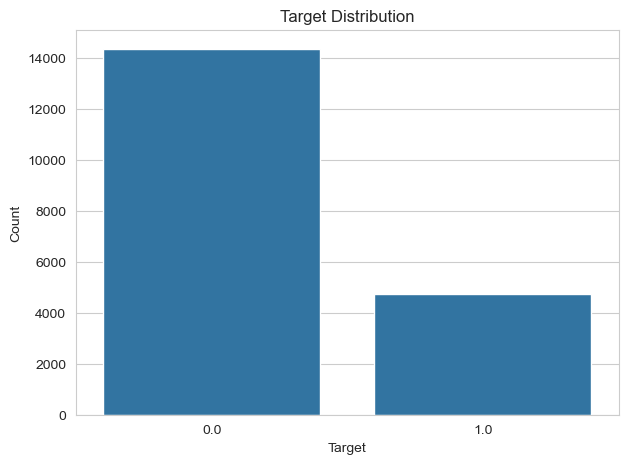

In [12]:
sns.countplot(x=y)
plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

Train test split 

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (15326, 158)
X_test shape: (3832, 158)
y_train shape: (15326,)
y_test shape: (3832,)


Train the baseline Decision Tree model

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, RocCurveDisplay

In [17]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Make predictions

In [19]:
y_pred = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)[:, 1]

Evaluate the baseline model 

In [26]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("ROC AUC:", round(roc_auc, 4))

Accuracy: 0.7218
Precision: 0.4414
Recall: 0.4377
F1 Score: 0.4395
ROC AUC: 0.6281


Classification report

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.81      0.82      0.81      2877
         1.0       0.44      0.44      0.44       955

    accuracy                           0.72      3832
   macro avg       0.63      0.63      0.63      3832
weighted avg       0.72      0.72      0.72      3832



Confusion matrix

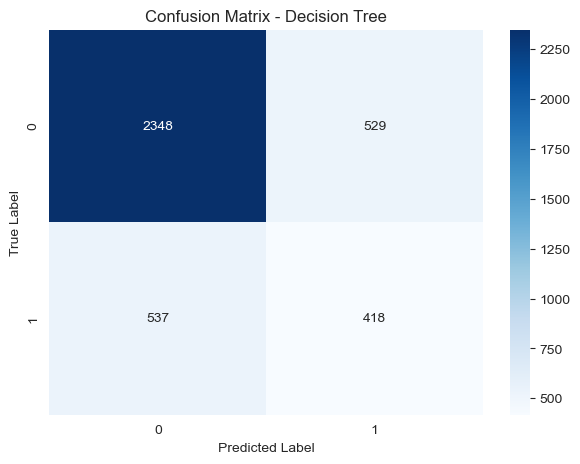

In [23]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

ROC curve

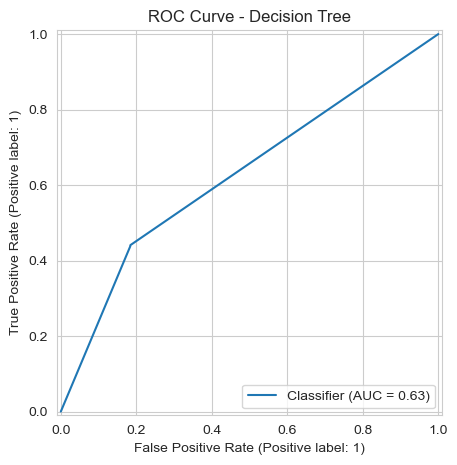

In [27]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Decision Tree")
plt.show()

Cross-validation score

In [29]:
from sklearn.model_selection import cross_val_score

In [30]:
cv_scores = cross_val_score(
    DecisionTreeClassifier(random_state=42),
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean CV F1 score:", cv_scores.mean())

Cross-validation F1 scores: [0.43472669 0.43721535 0.41958042 0.464582   0.4520202 ]
Mean CV F1 score: 0.4416249336238692


Check tree depth and number of leaves

In [31]:
print("Tree depth:", dt_model.get_depth())
print("Number of leaves:", dt_model.get_n_leaves())

Tree depth: 45
Number of leaves: 3483


Plot a simplified tree view

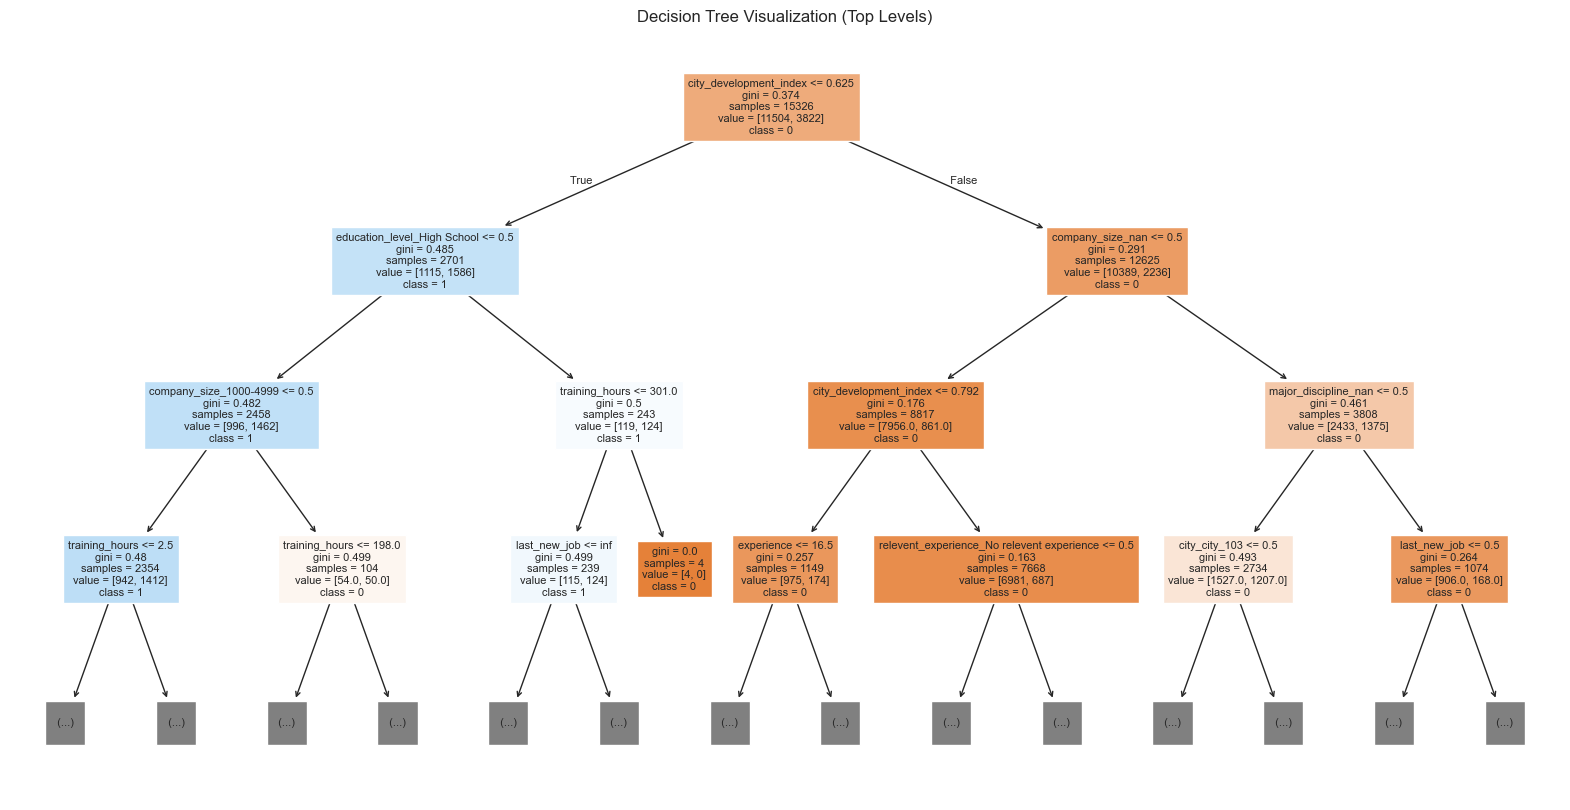

In [34]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["0", "1"],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree Visualization (Top Levels)")
plt.show()

Hyperparameter

In [36]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "class_weight": [None, "balanced"]
}

In [37]:
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [38]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1 Score:", grid_search.best_score_)

Best Parameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best Cross-Validation F1 Score: 0.615780389468074


Train the tuned model

In [39]:
best_dt = grid_search.best_estimator_
best_dt.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,7
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


Predict with tuned model

In [40]:
y_pred_best = best_dt.predict(X_test)
y_prob_best = best_dt.predict_proba(X_test)[:, 1]

Evaluate tuned model

In [41]:
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_prob_best)

print("Tuned Decision Tree Performance")
print("Accuracy :", round(accuracy_best, 4))
print("Precision:", round(precision_best, 4))
print("Recall   :", round(recall_best, 4))
print("F1-score :", round(f1_best, 4))
print("ROC-AUC  :", round(roc_auc_best, 4))

Tuned Decision Tree Performance
Accuracy : 0.7722
Precision: 0.53
Recall   : 0.7581
F1-score : 0.6239
ROC-AUC  : 0.8015


Classification report for tuned model 

In [42]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

         0.0       0.91      0.78      0.84      2877
         1.0       0.53      0.76      0.62       955

    accuracy                           0.77      3832
   macro avg       0.72      0.77      0.73      3832
weighted avg       0.81      0.77      0.78      3832

